Processing code for PL histograms with both single and multi-gaussian fitting and a stretched exponential fitting scatter plots for any time series. 
- Ensure any files are saved in chronological order
- Needs input of image time and skip rows (dependant on file saving format)
- All histograms need to be input as .txt files.
- Image time should be in seconds (take into account any potential error in image time i.e. for 85s use 90s).
- Tkinter used to select save files (if wanting to save as jpeg uncomment whichever graphs are needed.)
- Multi-gaussian fit is limited to 2 peaks per multi-gaussian
- FWHM is taken from largest peak of multiguassian

In [8]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

Using Tkinter to open popup for folder path of histograms and for saving all plots to .jpeg files (can be changed if needed but other sections may need formatting) 

In [9]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
folder_path1 = filedialog.askdirectory(title='Select input folder: Unpassivated')
bckg1 = filedialog.askopenfilename(title='Select bckg .txt file: Unpassivated')#,filetypes = ["*.txt"])
folder_path2 = filedialog.askdirectory(title='Select input folder: Passivated')
bckg2 = filedialog.askopenfilename(title='Select bckg .txt file: Passivated')#,filetypes = ["*.txt"])
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=1000, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

If pop up box not seen minimise spyder and select folder wanted for analysis


In [10]:
#Starting timer for runtime 
import time
start_time = time.time()

Using this section to set colourbars for histogram fitting. Change c1 and c2 as min and max colours (current is colourblind friendly). 

In [11]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen, aim for depth perceptive colour schemes

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink

Fitting for a single gaussian (not as accurate but sets a baseline for any changes that occur in the multi-gaussian fitting). 

In [48]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Gaussian fitting function using data from a dataset (i.e. from each individual file) 
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        min_raw=np.min(x_data)
        mean_raw=np.mean(x_data)
        max_raw=np.max(x_data)
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
       
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov, min_raw, mean_raw, max_raw

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

#Fitting for single gaussian
def fit_gaussian_from_files(file_directory, rows, image_time, bckg, int_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    gaussian_scatter=[]
    gaussian_min = []
    gaussian_max = []
    fwhm_scatter = []
    t=-int(image_time)
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.set_yticks([0], labels=["0"])
    ax.tick_params(axis='both', labelsize=20)
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = 20)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=20)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    
    # Loop through files in the specified directory
 #   for filename in os.listdir(file_directory):
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}")
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
        # Import bckg and adjust for bckg
        with open(bckg, 'r', encoding='utf-8', errors='replace') as f:
            bckg_data = np.loadtxt(f, skiprows=rows)
        x_bckg =bckg_data[:,0]
        y_bckg = bckg_data[:,1]
        y_data = np.subtract(y_data,y_bckg)
        adjustment = 10000/int_time
        y_data = [i*adjustment for i in y_data]
    
        # Fit the Gaussian curve to this dataset
        A, mu, sigma, popt, pcov, min_raw, mean_raw, max_raw = fit_gaussian_from_dataset(x_data, y_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        y_fit=gaussian(x_data,*popt)
        #for finding peak centre for fitted gaussian
        peak_index=np.argmax(y_fit)
        x_fit_max=x_data[peak_index]
        gaussian_scatter.append(x_fit_max)
        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm / 2
        x_right = highest['cen'] + fwhm / 2
        
        # Store in lists for output
        gaussian_min.append(x_left)
        gaussian_max.append(x_right)
        fwhm_scatter.append(fwhm)
        #Uncomment for debugging: 
        #print(f"Min:{min_scatter}\n Mean: {mean_scatter}\n Max: {max_scatter}")
        #print(time_scatter)
        # If fitting was successful, plot the result
        if A is not None:
            
            plt.scatter(x_data, y_data, label=f"{t}s", color=colors[idx], s=10)
            plt.plot(x_data, y_fit, label=f"_nolegend_", color=colors[idx], linewidth=2)
            plt.title(f"Single Gaussian Fitting", size=20)
            plt.xlabel("Wavelength (nm)", size=20)
            plt.ylabel("Intensity", size=20)
            plt.autoscale()
            #plt.legend()
                
    print("All gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=20)
    cbar.ax.tick_params(labelsize=20)
    plt.autoscale(enable=True, axis='y', tight=False)
    #ax.set_ylim(ymin=0)
    #Comment out if no file saving required
    #fig=plt.gcf()
    #save_plot_to_folder(fig, save_path, filename='PL_singlegaussian.jpeg')
    return min_scatter, mean_scatter, max_scatter, time_scatter, gaussian_scatter, fwhm_scatter
    plt.show() #Keep after saving figure due to errors. 

Multi-gaussian fitting function. Change estimate_guess_from_data --> wid =0.001 (based on current data) so change according to histogram width tolerance (either 0.1, 0.01 or 0.001). Runs through all files within folder. If initial time index is not 0 change this in the image time within function)

In [49]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y


# Auto-generate initial guess based on data
#def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
#    y_smooth = gaussian_filter1d(y, sigma=2)
#    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
#    
#    # Sort peaks by height (amplitude) and limit to top 2
#    if len(peaks) > 2:
#        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
#        peaks = peaks[sorted_indices]

#    guess = []
#    for i in peaks:
#        amp = y[i]
#        cen = x[i]
#        wid = 0.001 # Adjust based on data
#        guess += [amp, cen, wid]
#    
#    return guess, len(peaks)

def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    
    # 1. Capture both the peaks (indices) and the properties in the FIRST call
    peaks, properties = find_peaks(y_smooth, prominence=prominence, distance=distance)

    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        # 2. Use the already defined 'properties' variable
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices] # Update peaks to only include the top 2

    # The rest of the function proceeds only with the 1 or 2 highest peaks
    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]

    return guess, len(peaks)
#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_directory, rows, image_time, bckg, int_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    multigaussian_min = []
    multigaussian_max = []
    multigaussian_peak=[]
    fwhm_scatter= []
    t=-int(image_time)
    #Plotting parameters
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=20)
    plt.yticks(y, "")
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = 20)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", size=20)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
    
        file_path = os.path.join(file_directory, filename)
        print(f"\nProcessing file: {filename}") #Use if you want each individual file processed
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
        # Import bckg and adjust for bckg
        with open(bckg, 'r', encoding='utf-8', errors='replace') as f:
            bckg_data = np.loadtxt(f, skiprows=rows)
        x_bckg =bckg_data[:,0]
        y_bckg = bckg_data[:,1]
        y_data = np.subtract(y_data,y_bckg)
        adjustment =int(10000/int_time)
        y_data = [i*adjustment for i in y_data]
        
        # Estimate initial guess and peak count
        initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
        min_raw=np.min(x_data)
        max_raw=np.max(x_data)
        mean_raw=np.mean(x_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        y_fit=multi_gaussian(x_data,*popt)
        peak_index_max=np.argmax(y_fit)
        x_peak_centre=x_data[peak_index_max]
        multigaussian_peak.append(x_peak_centre)

        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm / 2
        x_right = highest['cen'] + fwhm / 2

        # Store in lists for output
        multigaussian_min.append(x_left)
        multigaussian_max.append(x_right)
        # Optional: print for debugging
        #print(f"  Highest Peak at x = {highest['cen']:.4f}")
        #print(f"  FWHM = {fwhm:.4f} → Bounds: [{x_left:.4f}, {x_right:.4f}]")
        
        if n_peaks is not None:
            # Plot
            plt.scatter(x_data, y_data, label=f"{t}s",color=colors[idx], s=10)
            plt.plot(x_data, multi_gaussian(x_data, *popt), label=f"_nolegend_", color=colors[idx],linewidth=2)
            plt.title(f"Multi-Gaussian Fitting", size=20)
            plt.xlabel("SPV(V)", size=20)
            plt.ylabel("Distribution $V^{-1}$", size=20)
            plt.autoscale()
        #plt.legend()
        #plt.tight_layout()
            #plt.show()
    print("All multi gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=20)
    cbar.ax.tick_params(labelsize=20)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
 #   fig=plt.gcf()
  #  save_plot_to_folder(fig,save_path,filename='MultiGaussian_Histogram.jpeg')
    return mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak, fwhm
    plt.show()    

Set image time and number of rows to skip within .txt files. Call x and y data for scatter plots from either single or multi-gaussian and raw or fitted data. 

Processing files: 100%|██████████| 10/10 [00:01<00:00,  6.46it/s]


All gaussians processed. Congrats!


Processing files: 100%|██████████| 10/10 [00:01<00:00,  6.78it/s]


All gaussians processed. Congrats!


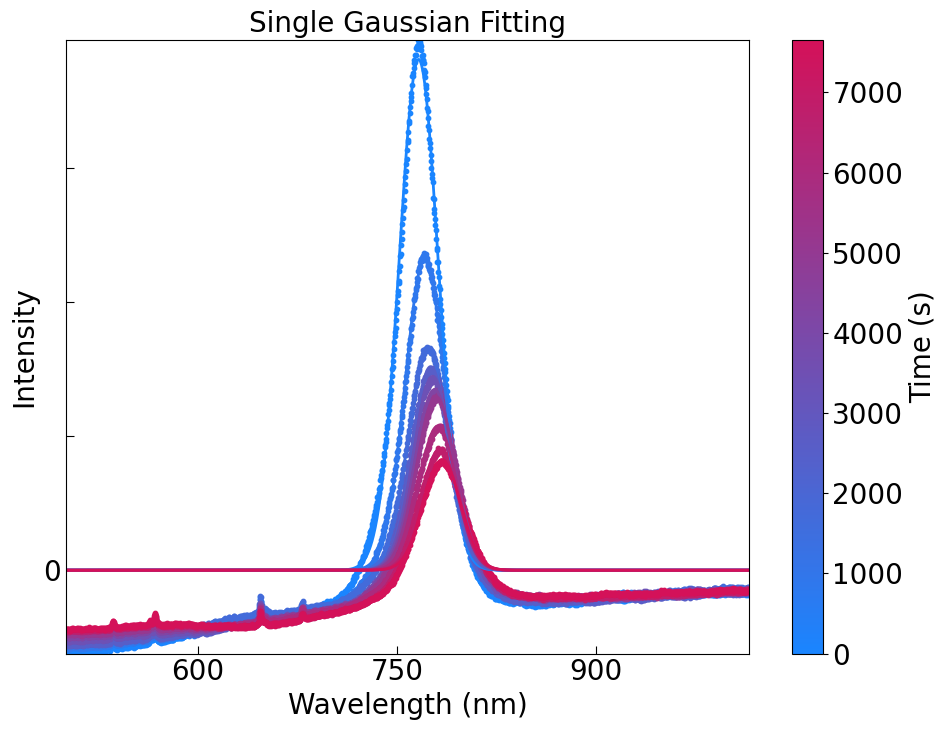

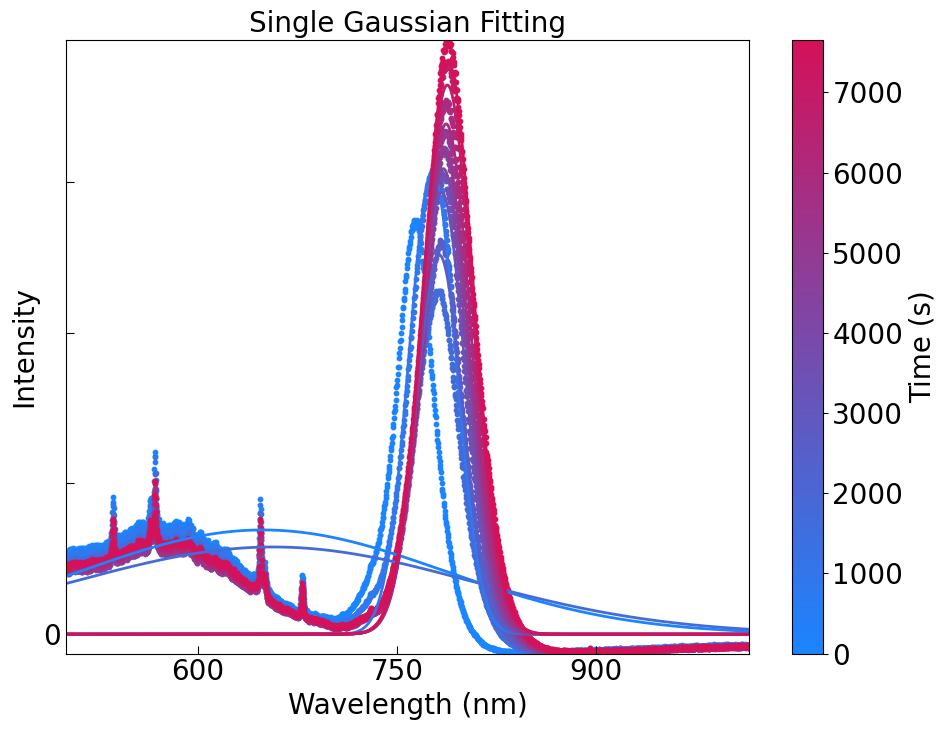

In [59]:
#Outputting single and multi gaussian plots:
#Uncomment folder_path input or copy into code directly if tkinter not working
#Can uncomment inputs if this varies between experiments
#folder_path=input("What is the folder path?")
#folder_path=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\250312_RG0087_KPFM\Histograms\CPD copy\LightOn" # Replace with your folder path
#rows=int(input("How many rows should be skipped?"))
rows1 = 446
rows2 = 446
#image_time=int(input("What was the image time?(in seconds)"))
image_time= 850 #seconds
int_time1 = 25 
int_time2 = 300
#print(folder_path)
min1,mean1,max1,time1, gaussian_scatter1, gauss_fwhm1=fit_gaussian_from_files(folder_path1,rows1,image_time, bckg1, int_time1)
min2,mean2,max2,time2, gaussian_scatter2, gauss_fwhm2=fit_gaussian_from_files(folder_path2,rows2,image_time, bckg2, int_time2)
#mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak, mutli_fwhm= multi_gaussian_folder(folder_path, rows, image_time, bckg, int_time)
#mean2, time2, min2, max2, gaussian_scatter2, gauss_fwhm2 = multi_gaussian_folder(folder_path2, rows, image_time, bckg2, int_time2)
x_data=time #Change according to whether using single or multi gaussian

#y_data = gaussian_scatter # Good check for if there is strange behaviour from the multi-gaussian fit. 



In [60]:
print(len(gaussian_scatter1),len(gaussian_scatter2))
print(len(gauss_fwhm1), len(gauss_fwhm2))
print(len(time1), len(time2))

10 10
10 10
10 10


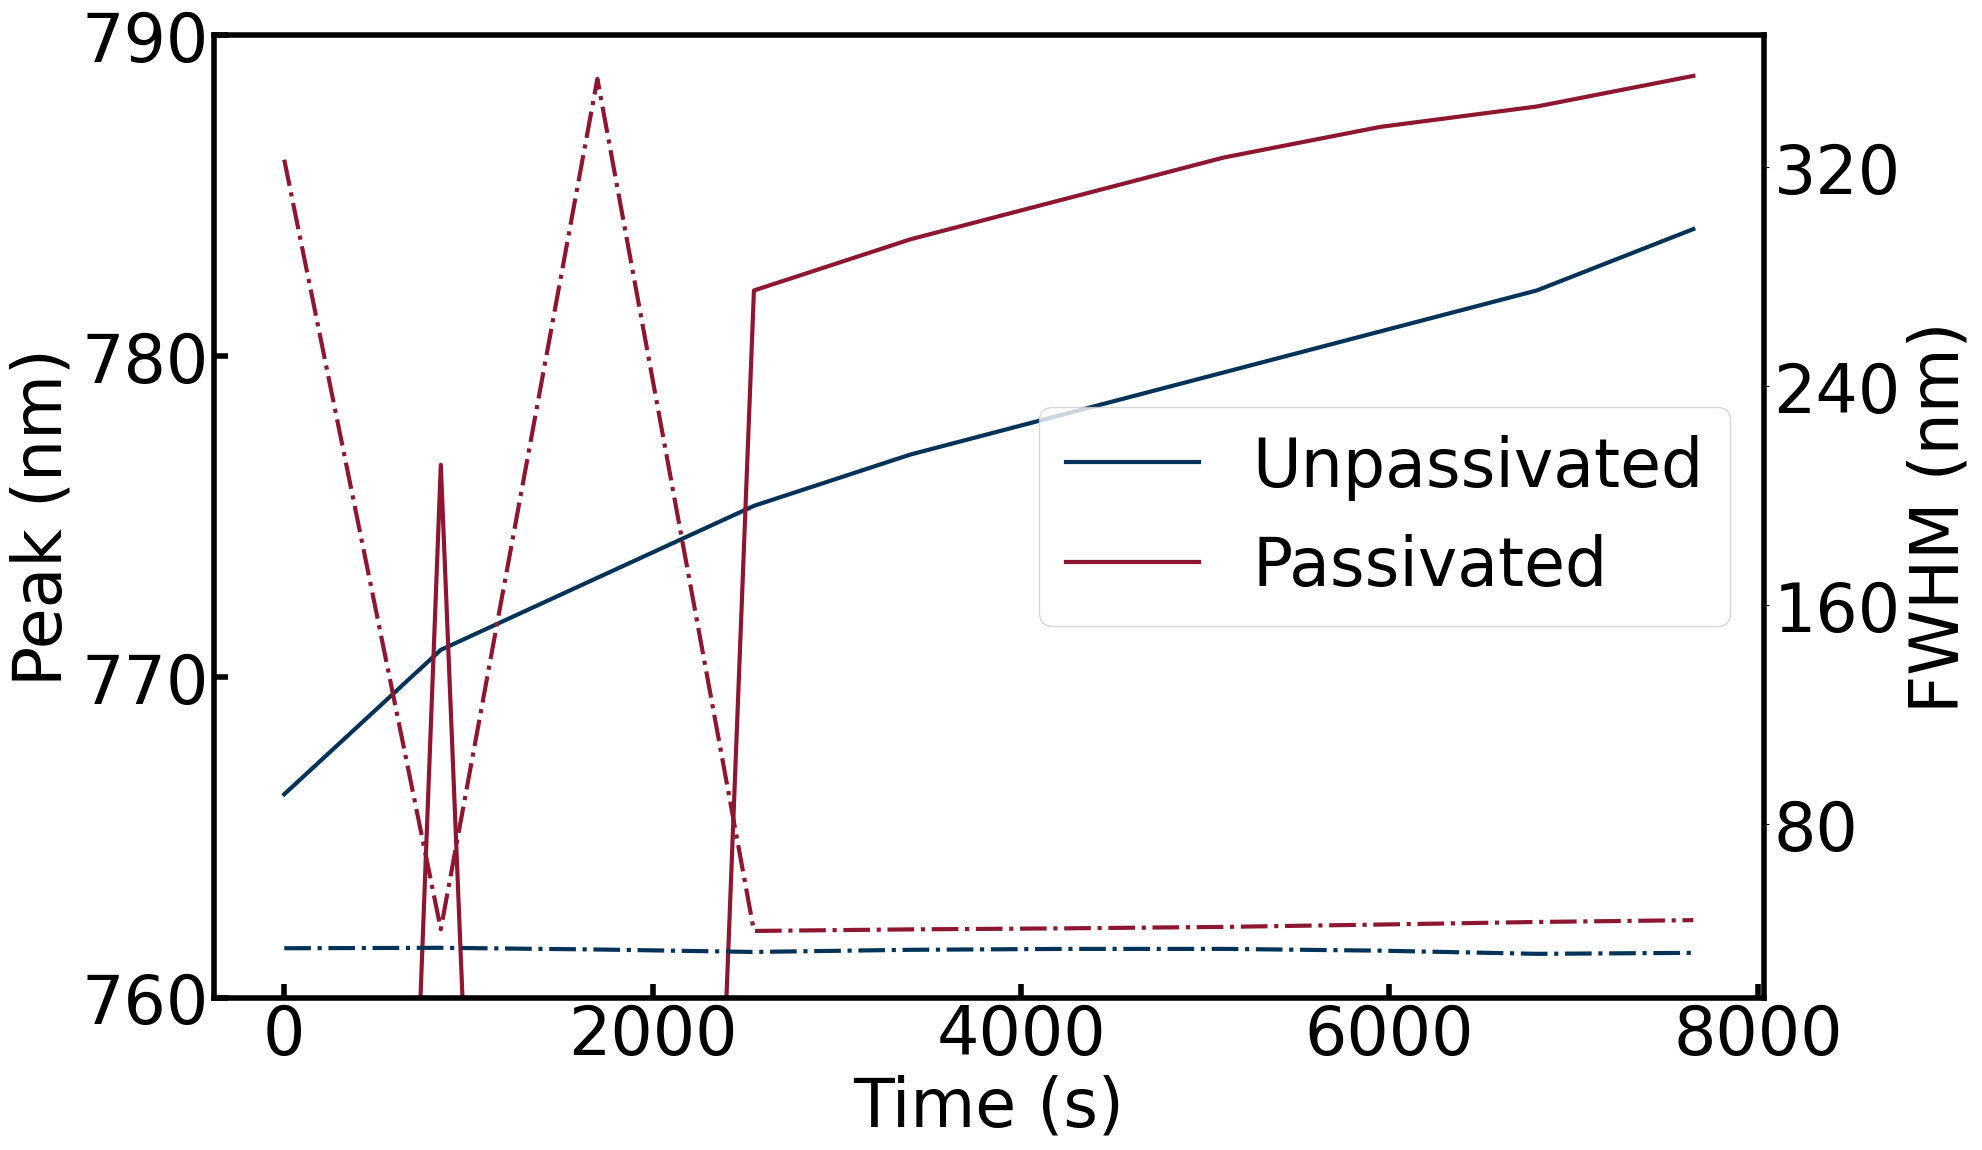

In [61]:
#Plotting: 
plt.subplots(figsize=(20,12.5))
ax = plt.gca()
plt.rcParams.update({'font.size': 48})
ax.tick_params(direction='in', length=10, width=4)
ax.tick_params(axis='both', labelsize=48)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(4)
# Create some mock data
t = time1
data1 = gaussian_scatter1
data2 = gauss_fwhm1
data3 = gaussian_scatter2
data4 = gauss_fwhm2

#fig, ax1 = plt.subplots(figsize=(20,12.5))

ax.set_xlabel('Time (s)', fontsize = 48)
ax.set_ylabel('Peak (nm)',fontsize = 48)
ax.plot(t, data1, '-', label = 'Unpassivated', color="#003357", linewidth=3)
ax.plot(t, data3, '-', label = 'Passivated', color="#8D1730", linewidth=3)
ax.tick_params(axis='y')
ax.set_ylim(760, 790)
#ax.set_ylabel(r"Peak (nm)")
plt.legend(loc="center right")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=3)) 

ax2 = ax.twinx()  #instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('FWHM (nm)',fontsize = 48)  # we already handled the x-label with ax1
ax2.plot(t, data2, '-.', label = 'Unpassivated',color="#003357", linewidth=3)# color="#5CBBFF", linewidth=3)
ax2.plot(t, data4, '-.', label = 'Passivated', color="#8D1730", linewidth=3)#color="#D69AAB", linewidth=3)
ax2.tick_params(axis='y')
ax2.set_ylim(0,100)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
ax2.spines[axis].set_linestyle('--')
plt.autoscale(enable=True, axis='both', tight=False)
#plt.legend(loc="lower center")

#fig=plt.gcf()
#save_plot_to_folder(fig, save_path,filename='PL_FWHM_Peak_LinePlotALL.jpeg')

#fig.tight_laytout()  # otherwise the right y-label is slightly clipped
plt.show()




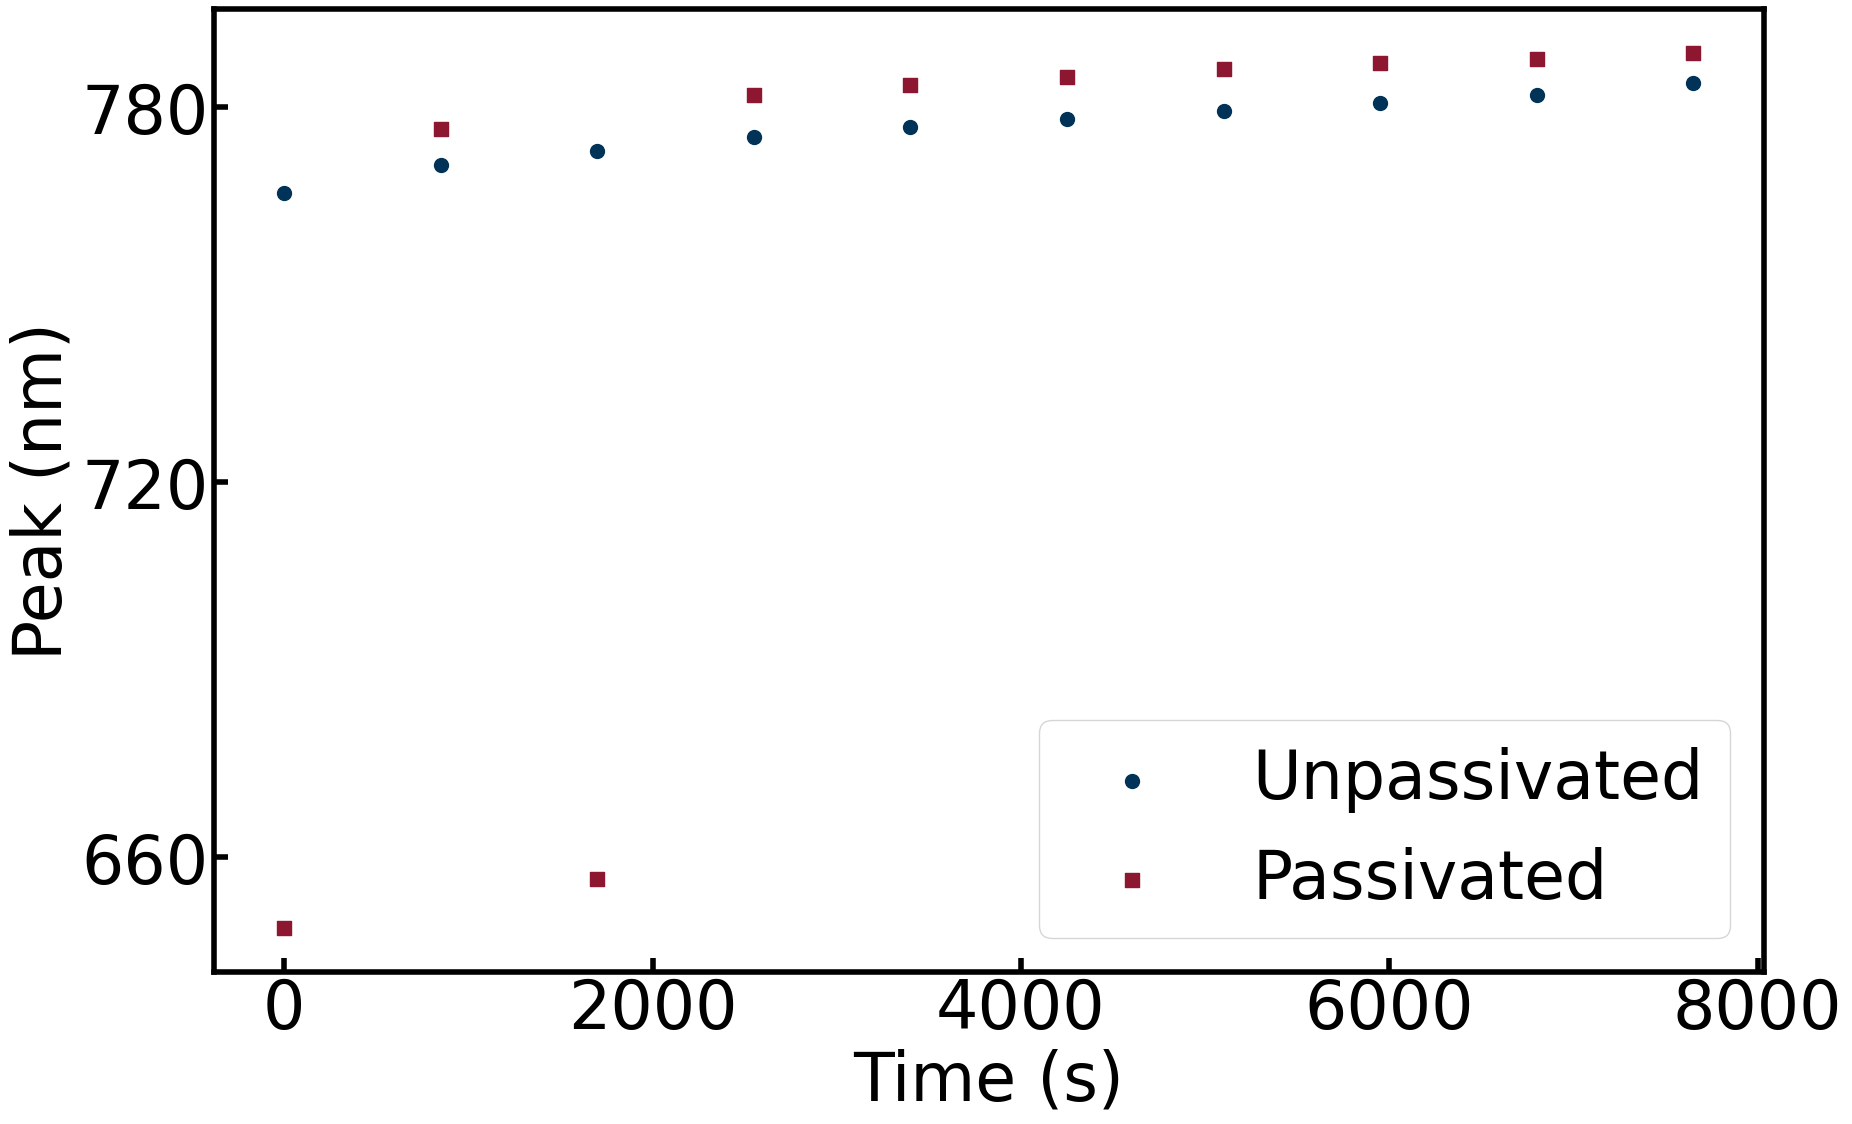

In [62]:
# Create arrays for plotting
t = time1
data1 = gaussian_scatter1
data2 = gauss_fwhm1
data3 = gaussian_scatter2
data4 = gauss_fwhm2
def adjusted_exponential(t, A, tau, const):
    return A*(1-np.exp(-(t/tau)))+const
    
def fitting_exponential(x_data, y_data):    
    try: 
        # Fit the data using curve_fit
        #defining initial guesses: 
        A_initial = np.max(y_data)#If data is positive then this should be max, if negative then it is min
        tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works
        const_initial=np.min(y_data)
        print(f"Constant initial = {const_initial:.2f}")
        initial_guess = [A_initial,tau_initial, const_initial]  # Initial guess for A, tau, const
        params, covariance = curve_fit(adjusted_exponential, x_data, y_data, p0=initial_guess, maxfev=1000000)
        #k_initial = 1/tau_initial
        # Extract the parameters (A, tau, beta)
        A, tau, const = params
        print("Fitted Parameters:")
        print(f"A = {A:.2f}")
        print(f"tau = {tau:.2f}")
        print(f"constant={const:.2f}")


        # Generate 1000 new x values between the minimum and maximum of original x_data
        x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        #y_fit= adjusted_exponential(x_fit, *params)
        y_fit = np.array([adjusted_exponential(np.array([x]), *params)[0] for x in tqdm(x_fit, desc="Fitting")])
    except Exception as e: 
        print("Fitting has failed. See errors or just come back later.")
        print(e.args)
    return x_fit, y_fit


#data1_xfit, data1_yfit = fitting_exponential(t, data1)
#data3_xfit, data3_yfit = fitting_exponential(t, data3)

#Plotting: 
plt.subplots(figsize=(20,12.5))
ax = plt.gca()
plt.rcParams.update({'font.size': 48})
ax.tick_params(direction='in', length=10, width=4)
ax.tick_params(axis='both', labelsize=48)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(4)


#fig, ax1 = plt.subplots(figsize=(20,12.5))

ax.set_xlabel('Time (s)', fontsize = 48)
ax.set_ylabel('Peak (nm)',fontsize = 48)
ax.scatter(t, data1, label = 'Unpassivated', color="#003357", s=100, marker = "o")
ax.scatter(t, data3, label = 'Passivated', color="#8D1730", s=100, marker = "s")
#ax.plot(data1_xfit, data1_yfit, '-', color="#003357", linewidth=3)
#ax.plot(data3_xfit, data3_yfit, '-', color="#8D1730", linewidth=3)
ax.tick_params(axis='y')
ax.set_ylim(760, 790)
#ax.set_ylabel(r"Peak (nm)")
plt.legend(loc="lower left")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=3)) 

#ax2 = ax.twinx()  #instantiate a second Axes that shares the same x-axis

#ax2.set_ylabel('FWHM (nm)',fontsize = 48)  # we already handled the x-label with ax1
#ax2.plot(t, data2, '--', label = 'FWHM', color="#5CBBFF", linewidth=3)
#ax2.tick_params(axis='y')
#ax2.set_ylim(0,100)
#ax2.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
plt.autoscale(enable=True, axis='both', tight=False)
plt.legend(loc="lower right")

#fig=plt.gcf()
#save_plot_to_folder(fig, save_path,filename='PL_FWHM_Peak_LinePlotUnpassivated.jpeg')

#fig.tight_laytout()  # otherwise the right y-label is slightly clipped
plt.show()


#Plotting: 
#plt.subplots(figsize=(20,12.5))
#ax = plt.gca()
#plt.rcParams.update({'font.size': 48})
#ax.tick_params(direction='in', length=10, width=4)
#ax.tick_params(axis='both', labelsize=48)
#for axis in ['top','bottom','left','right']:
#    ax.spines[axis].set_linewidth(4)
#fig, ax1 = plt.subplots(figsize=(20,12.5))

#ax.set_xlabel('Time (s)', fontsize = 48)
#ax.set_ylabel('Peak (nm)',fontsize = 48)
#ax.plot(t, data3, '-', label = 'Peak', color="#8D1730", linewidth=3)
#ax.tick_params(axis='y')
#ax.set_ylim(760, 790)
#ax.set_ylabel(r"Peak (nm)")
#plt.legend(loc="lower center")
#ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
#ax.yaxis.set_major_locator(MaxNLocator(nbins=3)) 

#ax2 = ax.twinx()  #instantiate a second Axes that shares the same x-axis

#ax2.set_ylabel('FWHM (nm)',fontsize = 48)  # we already handled the x-label with ax1
#ax2.plot(t, data4, '--', label = 'FWHM', color="#D69AAB", linewidth=3)
#ax2.tick_params(axis='y')
#ax2.set_ylim(0,100)
#ax2.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
#plt.autoscale(enable=True, axis='both', tight=False)
#plt.legend(loc="lower right")

#fig=plt.gcf()
#save_plot_to_folder(fig, save_path,filename='PL_FWHM_Peak_LinePlotPassivated.jpeg')

#fig.tight_laytout()  # otherwise the right y-label is slightly clipped
#plt.show()


Completing stretched exponential and adjusted exponential fitting and plotting. Values output for guesses onto the plot in a textbox. 
can omit running this step if just aiming to output gaussian's. 

In [63]:
#Runtime check: 
import time
end_time = time.time()
elapsed = end_time-start_time
print(f'Total runtime is {elapsed:.3f} seconds')

Total runtime is 818.880 seconds
